# Regional distribution of PoR life-cycle impacts

This notebook compares where the characterized life-cycle contributions of the **CL** and **OCE** scenarios occur, using the activity-location dimension retained by `pathways`. It works from an existing `results_*.gzip` export and does not rerun the LCA.

The analysis distinguishes:

1. **NL-located activities**: activities whose exact location is `NL`;
2. **Explicitly outside NL**: activities with an explicit non-NL country or subnational location;
3. **Aggregate / unresolved geography**: broad regions such as `RER`, `EUR`, `GLO` and `RoW` that may partly overlap the Netherlands.

> **Interpretation:** this is a contribution analysis by the location of the activity generating the inventory flow. It is not, by itself, a spatially regionalized LCIA method. It also cannot separate the Port of Rotterdam from other Dutch background activities, because both currently use location `NL`.


In [9]:
from pathlib import Path
import re
import textwrap

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------
RESULTS_FILE = None  # e.g. Path("results_20261006_082755.gzip"); None = newest export
FOCUS_YEAR = 2050
FOCUS_IMPACT = "EF v3.1 - climate change - global warming potential (GWP100)"
SAVE_FIGURES = True
FIGURE_DIR = Path("figs")

SCENARIO_NAMES = {
    "SSP2-PkBudg1000 - fc_nz - CL": "CL",
    "SSP2-PkBudg1000 - fc_nz - OCE": "OCE",
}

SCOPE_ORDER = [
    "NL-located activities",
    "Explicitly outside NL",
    "Aggregate / unresolved geography",
]

SCOPE_COLORS = {
    "NL-located activities": "#0072B2",
    "Explicitly outside NL": "#D55E00",
    "Aggregate / unresolved geography": "#B7B7B7",
}
SCOPE_HATCHES = {
    "NL-located activities": None,
    "Explicitly outside NL": None,
    "Aggregate / unresolved geography": "////",
}

IMPACT_UNITS = {
    "IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2, incl. SLCFs) - global warming potential (GWP100)": "kg CO$_2$-eq.",
    "EF v3.1 - climate change - global warming potential (GWP100)": "kg CO$_2$-eq.",
    "EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh)": "CTUh",
    "EF v3.1 - particulate matter formation - impact on human health": "disease incidence",
    "EF v3.1 - acidification - accumulated exceedance (AE)": "mol H$^+$-eq.",
    "EF v3.1 - ecotoxicity: freshwater - comparative toxic unit for ecosystems (CTUe)": "CTUe",
    "EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE)": "mol N-eq.",
    "EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)": "kg Sb-eq.",
}


## Load and validate the Pathways results

By default, the newest `results_*.gzip` file in the repository is selected. Set `RESULTS_FILE` above to make a specific export explicit and fully reproducible.


In [10]:
if RESULTS_FILE is None:
    candidates = sorted(
        Path.cwd().glob("results_*.gzip"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(
            "No results_*.gzip export found. Run p.export_results() first, "
            "or set RESULTS_FILE explicitly."
        )
    results_path = candidates[0]
else:
    results_path = Path(RESULTS_FILE)

if not results_path.exists():
    raise FileNotFoundError(results_path)

required_columns = {
    "act_category",
    "variable",
    "year",
    "region",
    "location",
    "model",
    "scenario",
    "impact_category",
    "value",
}

df = pd.read_parquet(results_path, engine="pyarrow")
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Results file is missing columns: {sorted(missing_columns)}")

df = df.loc[df["value"].notna() & df["value"].ne(0)].copy()
df["year"] = df["year"].astype(int)

if FOCUS_IMPACT not in set(df["impact_category"]):
    available = "\n - ".join(sorted(df["impact_category"].unique()))
    raise ValueError(f"FOCUS_IMPACT not found. Available methods:\n - {available}")

metadata = pd.Series(
    {
        "Results file": results_path.name,
        "Non-zero result rows": f"{len(df):,}",
        "Scenarios": ", ".join(map(str, df["scenario"].drop_duplicates())),
        "Years": ", ".join(map(str, sorted(df["year"].unique()))),
        "Impact categories": df["impact_category"].nunique(),
        "Activity locations": df["location"].nunique(),
    },
    name="Value",
)
display(metadata.to_frame())


,Value
Results file,results_20261006_082755.gzip
Non-zero result rows,"1,882,023"
Scenarios,"SSP2-PkBudg1000 - fc_nz - CL, SSP2-PkBudg1000 ..."
Years,"2025, 2030, 2035, 2040, 2045, 2050"
Impact categories,16
Activity locations,301


## Classify activity locations

Only exact country and subnational codes are called explicitly outside NL. Broader regions are retained as unresolved because many of them overlap NL. This conservative rule avoids treating all European or global datasets as physically foreign.


In [11]:
ISO2_PATTERN = re.compile(r"^[A-Z]{2}$")
SUBNATIONAL_PATTERN = re.compile(r"^[A-Z]{2}-[A-Z0-9]+$")

def classify_activity_location(location):
    """Return a conservative geographic scope for an activity location."""
    location = str(location).strip()
    if location == "NL" or location.startswith("NL-"):
        return "NL-located activities"
    if ISO2_PATTERN.fullmatch(location) or SUBNATIONAL_PATTERN.fullmatch(location):
        return "Explicitly outside NL"
    return "Aggregate / unresolved geography"

df["burden_location"] = df["location"].map(classify_activity_location)
df["burden_location"] = pd.Categorical(
    df["burden_location"], categories=SCOPE_ORDER, ordered=True
)

scope_df = (
    df.groupby(
        ["scenario", "year", "impact_category", "burden_location"],
        observed=True,
        as_index=False,
    )["value"]
    .sum()
)

# Integrity check: geographic aggregation must preserve every calculated value.
original_total = df["value"].sum()
scope_total = scope_df["value"].sum()
assert np.isclose(original_total, scope_total, rtol=1e-10, atol=1e-8), (
    original_total,
    scope_total,
)

location_inventory = (
    df[["location", "burden_location"]]
    .drop_duplicates()
    .sort_values(["burden_location", "location"])
    .reset_index(drop=True)
)
display(
    location_inventory.groupby("burden_location", observed=True)
    .size()
    .rename("Number of activity locations")
    .to_frame()
)
display(location_inventory.head(20))


,Number of activity locations
burden_location,
NL-located activities,1
Explicitly outside NL,252
Aggregate / unresolved geography,48


,location,burden_location
0,NL,NL-located activities
1,AE,Explicitly outside NL
2,AL,Explicitly outside NL
3,AM,Explicitly outside NL
4,AR,Explicitly outside NL
5,AT,Explicitly outside NL
6,AU,Explicitly outside NL
7,AU-NSW,Explicitly outside NL
8,AU-QLD,Explicitly outside NL
9,AU-SA,Explicitly outside NL


## Publication-style plotting helpers

Positive burdens and negative credits are stacked separately. This is essential for climate results containing biogenic uptake or carbon-storage credits.


In [12]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "axes.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "legend.fontsize": 7,
        "legend.frameon": False,
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

def scenario_label(value):
    if value in SCENARIO_NAMES:
        return SCENARIO_NAMES[value]
    match = re.search(r"(?:^| - )(CL|OCE)$", str(value))
    return match.group(1) if match else str(value)

def scenario_sort_key(value):
    label = scenario_label(value)
    preferred = {"CL": 0, "OCE": 1}
    return preferred.get(label, 99), label

def impact_label(value, include_method=True):
    raw = str(value)
    if raw.startswith("EF v3.1 - " ):
        method, core = "EF v3.1", raw.removeprefix("EF v3.1 - " )
    elif raw.startswith("IPCC 2021 (incl. biogenic CO2) - " ):
        method, core = "IPCC 2021 incl. biogenic CO$_2$", raw.removeprefix("IPCC 2021 (incl. biogenic CO2) - " )
    elif raw.startswith("RELICS - metals extraction - " ):
        method, core = "RELICS", "metal extraction · " + raw.removeprefix("RELICS - metals extraction - " )
    else:
        method, core = "", raw
    core = core.replace(" - global warming potential (GWP100)", " (GWP100)")
    core = core.replace(" - comparative toxic unit for ecosystems (CTUe)", " (CTUe)")
    core = core.replace(" - comparative toxic unit for human (CTUh)", " (CTUh)")
    core = core.replace(" - accumulated exceedance (AE)", " (AE)")
    return f"{method} · {core}" if include_method and method else core

def choose_scale(values, impact):
    max_abs = float(np.nanmax(np.abs(values))) if len(values) else 0.0
    unit = IMPACT_UNITS.get(impact, "impact units")
    if "climate change" in impact.lower() and "kg CO" in unit and max_abs >= 1e8:
        return 1e9, "Mt CO$_2$-eq."
    for factor, exponent in ((1e12, 12), (1e9, 9), (1e6, 6), (1e3, 3)):
        if max_abs >= factor:
            return factor, f"{unit} × 10$^{exponent}$"
    return 1.0, unit

def signed_stacked_bars(ax, x, values_by_scope, width=0.72):
    positive_bottom = np.zeros(len(x), dtype=float)
    negative_bottom = np.zeros(len(x), dtype=float)
    for scope in SCOPE_ORDER:
        values = np.asarray(values_by_scope.get(scope, np.zeros(len(x))), dtype=float)
        bottom = np.where(values >= 0, positive_bottom, negative_bottom)
        ax.bar(
            x,
            values,
            width=width,
            bottom=bottom,
            color=SCOPE_COLORS[scope],
            hatch=SCOPE_HATCHES[scope],
            edgecolor="white",
            linewidth=0.35,
            zorder=2,
        )
        positive_bottom += np.where(values >= 0, values, 0)
        negative_bottom += np.where(values < 0, values, 0)
    return positive_bottom, negative_bottom

def save_figure(fig, stem):
    if not SAVE_FIGURES:
        return
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

legend_handles = [
    Patch(
        facecolor=SCOPE_COLORS[s], edgecolor="white",
        hatch=SCOPE_HATCHES[s], label=s,
    )
    for s in SCOPE_ORDER
]
net_total_handle = mpl.lines.Line2D(
    [], [], color="#222222", marker="o", markersize=3.5,
    linewidth=1.0, label="Net total",
)


## Figure 1 — Regional contributions through time

Each scenario is shown in the same figure using a common vertical scale. Negative bars are environmental credits or removals, not avoided positive burdens.


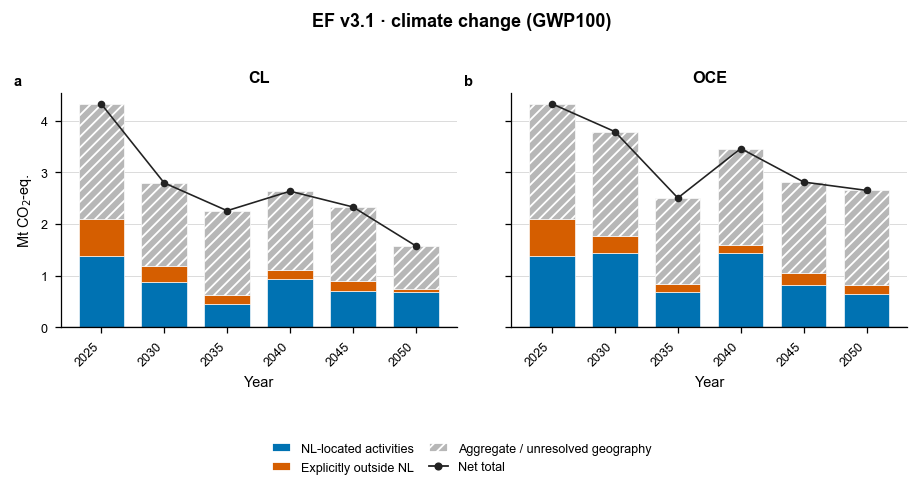

In [13]:
plot_data = scope_df.loc[scope_df["impact_category"].eq(FOCUS_IMPACT)].copy()
scenarios = sorted(plot_data["scenario"].drop_duplicates(), key=scenario_sort_key)
years = sorted(plot_data["year"].unique())
scale, scaled_unit = choose_scale(plot_data["value"].to_numpy(), FOCUS_IMPACT)

fig, axes = plt.subplots(
    1, len(scenarios),
    figsize=(3.55 * len(scenarios), 3.25),
    sharey=True,
    squeeze=False,
)

for panel, (ax, scenario) in enumerate(zip(axes.flat, scenarios)):
    subset = plot_data.loc[plot_data["scenario"].eq(scenario)]
    pivot = (
        subset.pivot_table(
            index="year", columns="burden_location", values="value",
            aggfunc="sum", observed=True, fill_value=0,
        )
        .reindex(index=years, columns=SCOPE_ORDER, fill_value=0)
        / scale
    )
    x = np.arange(len(years))
    signed_stacked_bars(ax, x, {scope: pivot[scope].to_numpy() for scope in SCOPE_ORDER})
    net_total = pivot.sum(axis=1).to_numpy()
    ax.plot(
        x, net_total, color="#222222", marker="o", markersize=3.2,
        linewidth=0.9, zorder=4,
    )
    ax.axhline(0, color="#333333", linewidth=0.7, zorder=3)
    ax.set_xticks(x, years, rotation=45, ha="right")
    ax.set_title(scenario_label(scenario), fontweight="bold", pad=6)
    ax.set_xlabel("Year")
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.text(-0.12, 1.03, chr(97 + panel), transform=ax.transAxes, fontweight="bold")

axes.flat[0].set_ylabel(scaled_unit)
fig.suptitle(impact_label(FOCUS_IMPACT), fontsize=10, fontweight="bold", y=1.02)
fig.legend(
    handles=legend_handles + [net_total_handle],
    loc="lower center", bbox_to_anchor=(0.5, -0.10),
    ncol=2, columnspacing=1.2, handlelength=1.5,
)
fig.tight_layout(rect=(0, 0.09, 1, 1))
save_figure(fig, "regional_impacts_over_time")
plt.show()


## Figure 2 — OCE–CL difference decomposed by geography

A positive value means that OCE has a higher burden than CL; a negative value means that OCE has a lower burden or a larger credit. The stacked components add exactly to the total scenario difference.


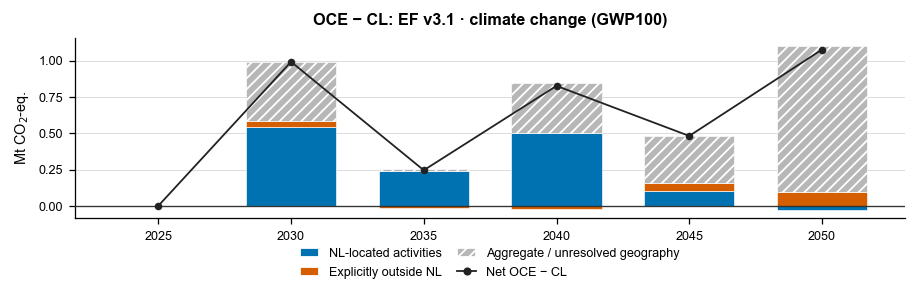

In [14]:
scenario_lookup = {scenario_label(s): s for s in scope_df["scenario"].unique()}
if not {"CL", "OCE"}.issubset(scenario_lookup):
    raise ValueError(
        "The difference figure requires scenarios identifiable as CL and OCE. "
        f"Found: {sorted(scenario_lookup)}"
    )

comparison = scope_df.loc[scope_df["impact_category"].eq(FOCUS_IMPACT)].copy()
wide = comparison.pivot_table(
    index=["year", "burden_location"],
    columns="scenario",
    values="value",
    aggfunc="sum",
    observed=True,
    fill_value=0,
).reset_index()
wide["difference"] = wide[scenario_lookup["OCE"]] - wide[scenario_lookup["CL"]]
difference = wide.pivot_table(
    index="year", columns="burden_location", values="difference",
    observed=True, fill_value=0,
).reindex(index=years, columns=SCOPE_ORDER, fill_value=0)

difference_scale, difference_unit = choose_scale(difference.to_numpy().ravel(), FOCUS_IMPACT)
difference_scaled = difference / difference_scale
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(7.1, 3.75))
positive, negative = signed_stacked_bars(
    ax, x, {scope: difference_scaled[scope].to_numpy() for scope in SCOPE_ORDER}, width=0.68
)
total_difference = difference_scaled.sum(axis=1).to_numpy()
ax.plot(x, total_difference, color="#222222", marker="o", markersize=3.2, linewidth=1.0, zorder=4, label="Net OCE − CL")
ax.axhline(0, color="#333333", linewidth=0.75, zorder=3)
ax.set_xticks(x, years)
# Years are explicit tick labels; omitting a repeated x-axis title keeps the legend clear.
ax.set_ylabel(difference_unit)
ax.set_title(f"OCE − CL: {impact_label(FOCUS_IMPACT)}", fontweight="bold", pad=7)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.5)
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(6))
difference_handle = mpl.lines.Line2D(
    [], [], color="#222222", marker="o", markersize=3.5,
    linewidth=1.0, label="Net OCE − CL",
)
ax.legend(
    handles=legend_handles + [difference_handle], loc="lower center",
    bbox_to_anchor=(0.5, -0.40), ncol=2, columnspacing=1.2, handlelength=1.5,
)
fig.tight_layout(rect=(0, 0.22, 1, 1))
save_figure(fig, "regional_impacts_oce_minus_cl")
plt.show()


## Figure 3 — Geographic composition across all impact categories

The heatmap reports each scope's share of the **gross absolute contribution** in the focus year. Cell colour represents magnitude; the `+` or `−` sign shows whether the corresponding net contribution is a burden or a credit. Absolute shares are used because percentages of a near-zero net total become meaningless when burdens and removals cancel.


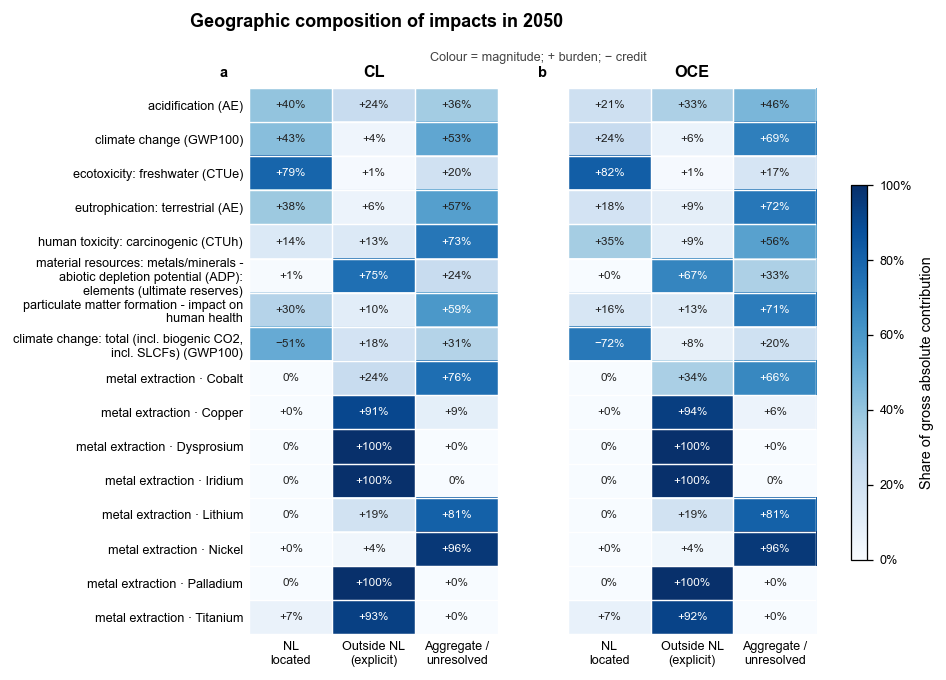

In [15]:
heat = scope_df.loc[scope_df["year"].eq(FOCUS_YEAR)].copy()
if heat.empty:
    raise ValueError(f"FOCUS_YEAR {FOCUS_YEAR} is not available in the results.")

heat["absolute_value"] = heat["value"].abs()
denominator = heat.groupby(
    ["scenario", "impact_category"], observed=True
)["absolute_value"].transform("sum")
heat["gross_absolute_share"] = np.divide(
    heat["absolute_value"],
    denominator,
    out=np.zeros(len(heat), dtype=float),
    where=denominator.ne(0),
)
heat["signed_gross_share"] = np.sign(heat["value"]) * heat["gross_absolute_share"]

# Preserve the method order from the Pathways export; impacts use different units,
# so ranking categories by their numerical totals would not be meaningful.
impact_order = heat["impact_category"].drop_duplicates().tolist()
wrapped_labels = [textwrap.fill(impact_label(i, include_method=False), width=42) for i in impact_order]
scenario_order = sorted(heat["scenario"].drop_duplicates(), key=scenario_sort_key)

fig, axes = plt.subplots(
    1, len(scenario_order),
    figsize=(3.25 * len(scenario_order) + 2.4, max(4.2, 0.36 * len(impact_order))),
    sharey=True,
    squeeze=False,
)

for panel, (ax, scenario) in enumerate(zip(axes.flat, scenario_order)):
    matrix = (
        heat.loc[heat["scenario"].eq(scenario)]
        .pivot_table(
            index="impact_category", columns="burden_location",
            values="gross_absolute_share", observed=True, fill_value=0,
        )
        .reindex(index=impact_order, columns=SCOPE_ORDER, fill_value=0)
    )
    signed_matrix = (
        heat.loc[heat["scenario"].eq(scenario)]
        .pivot_table(
            index="impact_category", columns="burden_location",
            values="signed_gross_share", observed=True, fill_value=0,
        )
        .reindex(index=impact_order, columns=SCOPE_ORDER, fill_value=0)
    )
    image = ax.imshow(
        matrix.to_numpy(), cmap="Blues", vmin=0, vmax=1,
        aspect="auto", interpolation="nearest",
    )
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix.iat[row, column]
            signed_value = signed_matrix.iat[row, column]
            sign = "−" if signed_value < 0 else "+" if signed_value > 0 else ""
            ax.text(
                column, row, f"{sign}{value:.0%}", ha="center", va="center",
                fontsize=6.5, color="white" if value >= 0.58 else "#222222",
            )
    ax.set_xticks(
        range(len(SCOPE_ORDER)),
        ["NL\nlocated", "Outside NL\n(explicit)", "Aggregate /\nunresolved"],
    )
    ax.set_yticks(range(len(impact_order)), wrapped_labels)
    ax.set_title(scenario_label(scenario), fontweight="bold", pad=6)
    ax.tick_params(length=0)
    ax.set_xticks(np.arange(-0.5, len(SCOPE_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(impact_order), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(-0.12, 1.02, chr(97 + panel), transform=ax.transAxes, fontweight="bold")

fig.subplots_adjust(
    left=0.39 if len(scenario_order) > 1 else 0.52, right=0.88,
    bottom=0.14, top=0.87, wspace=0.28,
)
colorbar_ax = fig.add_axes([0.91, 0.24, 0.014, 0.50])
colorbar = fig.colorbar(image, cax=colorbar_ax)
colorbar.set_label("Share of gross absolute contribution")
colorbar.ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
fig.suptitle(
    f"Geographic composition of impacts in {FOCUS_YEAR}",
    fontsize=10, fontweight="bold", y=0.97,
)
fig.text(
    0.64, 0.91, "Colour = magnitude; + burden; − credit",
    ha="center", va="center", fontsize=7, color="#444444",
)
save_figure(fig, f"regional_impact_composition_{FOCUS_YEAR}")
plt.show()


## Diagnostic tables

The first table gives signed regional contributions for the selected method and year. The second identifies the largest individual activity-location labels by absolute contribution. Broad labels in this table show where improved regionalization would be most valuable.


In [16]:
focus_table = scope_df.loc[
    scope_df["impact_category"].eq(FOCUS_IMPACT)
    & scope_df["year"].eq(FOCUS_YEAR)
].copy()
focus_table["scenario_short"] = focus_table["scenario"].map(scenario_label)
table_scale, table_unit = choose_scale(focus_table["value"].to_numpy(), FOCUS_IMPACT)
focus_table["value_scaled"] = focus_table["value"] / table_scale

signed_table = focus_table.pivot_table(
    index="scenario_short", columns="burden_location", values="value_scaled",
    observed=True, fill_value=0,
).reindex(columns=SCOPE_ORDER, fill_value=0)
signed_table["Net total"] = signed_table.sum(axis=1)
signed_table.columns.name = table_unit
display(signed_table.round(3))

top_locations = (
    df.loc[
        df["impact_category"].eq(FOCUS_IMPACT) & df["year"].eq(FOCUS_YEAR)
    ]
    .groupby(["scenario", "location", "burden_location"], observed=True, as_index=False)["value"]
    .sum()
)
top_locations["absolute_value"] = top_locations["value"].abs()
top_locations["scenario_short"] = top_locations["scenario"].map(scenario_label)
top_locations = (
    top_locations.sort_values(["scenario", "absolute_value"], ascending=[True, False])
    .groupby("scenario", observed=True)
    .head(12)
    .drop(columns="absolute_value")
)
display(top_locations[["scenario_short", "location", "burden_location", "value"]])


Mt CO$_2$-eq.,NL-located activities,Explicitly outside NL,Aggregate / unresolved geography,Net total
scenario_short,,,,
CL,0.674,0.062,0.837,1.573
OCE,0.649,0.160,1.840,2.649


,scenario_short,location,burden_location,value
199,CL,NL,NL-located activities,6.742995e+08
123,CL,GLO,Aggregate / unresolved geography,3.081387e+08
118,CL,Europe without Switzerland,Aggregate / unresolved geography,1.222113e+08
214,CL,RER,Aggregate / unresolved geography,1.084545e+08
222,CL,RoW,Aggregate / unresolved geography,7.911870e+07
117,CL,EUR,Aggregate / unresolved geography,7.873707e+07
215,CL,RER w/o RU,Aggregate / unresolved geography,2.558454e+07
73,CL,CN,Explicitly outside NL,2.066677e+07
229,CL,SSA,Aggregate / unresolved geography,1.436480e+07
70,CL,CHA,Aggregate / unresolved geography,1.429458e+07


## Recommended interpretation

- Treat **NL-located** as a Dutch activity-location result, not yet as an exact PoR boundary.
- Do not merge broad locations (`RER`, `EUR`, `GLO`, `RoW`, etc.) into “outside NL” without an allocation rule.
- Compare both absolute annual impacts and impacts normalized by a consistent product-output denominator when CL and OCE have different production volumes.
- For methods with negative credits, report signed contributions and gross absolute shares; avoid percentages of the net total.
- An exact **PoR / rest of NL / outside NL** split requires an activity-level PoR scope tag to be retained before Pathways aggregates results by activity category and location.
